In [30]:
import json 
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import cv2

In [31]:
with open("homo_kafka/kafka_messages_first.json","r", encoding="utf-8") as f:
    data = json.load(f)

print(data[:1000])

[{'timestamp': 1766405704261, 'partition': 0, 'offset': 1062, 'value': {'fisheye_233': {'bboxes': [[1142.666748046875, 306.0, 1280.0, 529.875]], 'dewrap_view': ['view4'], 'fisheye_positions_x_y': [[1019.08544921875, 1501.5465087890625]], 'frame_id': '1', 'object_classes': ['forklift'], 'object_confidences': [0.93359375], 'object_ids': [1], 'timestamp': '2025-12-22 12:15:04.261'}}}, {'timestamp': 1766405704263, 'partition': 0, 'offset': 1063, 'value': {'fisheye_234': {'bboxes': [], 'dewrap_view': [], 'fisheye_positions_x_y': [], 'frame_id': '1', 'object_classes': [], 'object_confidences': [], 'object_ids': [], 'timestamp': '2025-12-22 12:15:04.263'}}}, {'timestamp': 1766405704273, 'partition': 0, 'offset': 1064, 'value': {'fisheye_229': {'bboxes': [[564.3627319335938, 200.66616821289062, 672.0294189453125, 326.1036682128906], [905.3333740234375, 171.09375, 1256.0, 526.875]], 'dewrap_view': ['view1', 'view4'], 'fisheye_positions_x_y': [[1897.60205078125, 1141.4185791015625], [1103.765258

In [32]:
# Kafka message filter
fisheye_cam_id = ["fisheye_229", "fisheye_233","fisheye_234"]
fisheye_data = {cam:[] for cam in fisheye_cam_id}

pair = []
for i in fisheye_cam_id:
    for j in fisheye_cam_id:
        if i == j:
            continue
        if (j,i) not in pair:
            pair.append((i,j))
            
for msg in data:
    kafka_ts = msg.get("timestamp")
    value = msg.get("value", {})

    for cam_id, cam in value.items():
        if cam_id not in fisheye_cam_id:
            continue

        classes = cam.get("object_classes", [])
        positions = cam.get("fisheye_positions_x_y", [])

        for i, cls in enumerate(classes):
            if cls == "person" and i < len(positions):

                entry = {
                    "camera": cam_id,
                    "frame_id": cam.get("frame_id"),
                    "position": positions[i],
                    "camera_timestamp": cam.get("timestamp"),
                    "kafka_timestamp_ms": kafka_ts
                }

                fisheye_data[cam_id].append(entry)

# Processing
def undistort_points(pts, K_fish, D_fish, K_rect):
    pts = np.asarray(pts, np.float32).reshape(-1, 1, 2)
    out = cv2.fisheye.undistortPoints(pts, K_fish, D_fish, P=K_rect)
    return out.reshape(-1, 2)

fisheye_params = {
    "width": 2592, "height": 1944,
    "cx": 1296.0, "cy": 972.0,
    "radius": 952.56, "theta_max_rad": 1.5708
}

rect_w, rect_h = 2560, 2560
fov = 160  
focal = (rect_w / 2) / np.tan(np.deg2rad(fov) / 2)

K_rect = np.array([[focal, 0, rect_w/2],
                   [0, focal, rect_h/2],
                   [0, 0, 1]], np.float32)

f_fish = fisheye_params["radius"] / fisheye_params["theta_max_rad"]
K_fish = np.array([[f_fish, 0, fisheye_params["cx"]],
                   [0, f_fish, fisheye_params["cy"]],
                   [0, 0, 1]], np.float32)

D_fish = np.zeros((4, 1), np.float32)

TOL_MS = 10
MIN_EDGE_DIST = 40
undistorted_pair_points = {}
for p in pair:
    a,b = p
    fisheye_a_common = []
    fisheye_b_common = []

    fisheye_a_sorted = sorted(fisheye_data[a], key=lambda x: x["kafka_timestamp_ms"])
    fisheye_b_sorted = sorted(fisheye_data[b], key=lambda x: x["kafka_timestamp_ms"])
    i, j = 0, 0
    while i < len(fisheye_a_sorted) and j < len(fisheye_b_sorted):
        ts_a = fisheye_a_sorted[i]["kafka_timestamp_ms"]
        ts_b = fisheye_b_sorted[j]["kafka_timestamp_ms"]

        if abs(ts_a - ts_b) <= TOL_MS:
            fisheye_a_common.append(fisheye_a_sorted[i])
            fisheye_b_common.append(fisheye_b_sorted[j])
            i += 1
            j += 1
        elif ts_a < ts_b:
            i += 1
        else:
            j += 1

    print(f"Matched pairs {a} - {b}")

    pts_a = np.array([d["position"] for d in fisheye_a_common],dtype=np.float32)
    pts_b = np.array([d["position"] for d in fisheye_b_common],dtype=np.float32)
    hull_a_idx = set(cv2.convexHull(pts_a, returnPoints=False).squeeze().tolist())
    hull_b_idx = set(cv2.convexHull(pts_b, returnPoints=False).squeeze().tolist())
    common_idx = sorted(hull_a_idx & hull_b_idx)
    print("Polygon points:", len(common_idx))
    pts_a_final = pts_a[common_idx]
    pts_b_final = pts_b[common_idx]

    def ccw_order_indices(pts):
        center = np.mean(pts, axis=0)
        angles = np.arctan2(
            pts[:, 1] - center[1],
            pts[:, 0] - center[0]
        )
        return np.argsort(angles)

    order = ccw_order_indices(pts_a_final)

    pts_a_final = pts_a_final[order]
    pts_b_final = pts_b_final[order]
    keep = [0]
    for i in range(1, len(pts_a_final)):
        dist_a = np.linalg.norm(pts_a_final[i] - pts_a_final[keep[-1]])
        dist_b = np.linalg.norm(pts_b_final[i] - pts_b_final[keep[-1]])

        if dist_a >= MIN_EDGE_DIST and dist_b >= MIN_EDGE_DIST:
            keep.append(i)

    pts_a_final = pts_a_final[keep]
    pts_b_final = pts_b_final[keep]
    print("Final polygon points:", (pts_b_final.shape[0]))
    assert pts_a_final.shape == pts_b_final.shape
    assert pts_a_final.shape[0] >= 4
    ua = undistort_points(pts_a_final, K_fish, D_fish, K_rect)
    ub = undistort_points(pts_b_final, K_fish, D_fish, K_rect)
    key = f"pair_{a.split('_')[1]}_{b.split('_')[1]}"
    undistorted_pair_points[key] = [ua.tolist(), ub.tolist()]





Matched pairs fisheye_229 - fisheye_233
Polygon points: 10
Final polygon points: 8
Matched pairs fisheye_229 - fisheye_234
Polygon points: 15
Final polygon points: 11
Matched pairs fisheye_233 - fisheye_234
Polygon points: 5
Final polygon points: 5


In [33]:
undistorted_pair_points

{'pair_229_233': [[[1563.8514404296875, 1323.8583984375],
   [1639.3868408203125, 1379.8267822265625],
   [1683.642333984375, 1420.869384765625],
   [1417.42041015625, 2127.625],
   [1311.0863037109375, 2150.4814453125],
   [1231.6298828125, 2122.7685546875],
   [1107.566162109375, 2107.237060546875],
   [1226.6593017578125, 1694.7791748046875]],
  [[979.9051513671875, 1364.2833251953125],
   [1039.736083984375, 1331.98046875],
   [1089.2591552734375, 1321.437744140625],
   [1398.612548828125, 1600.3089599609375],
   [1374.63818359375, 1634.015869140625],
   [1326.50439453125, 1667.3292236328125],
   [1279.4080810546875, 1702.6842041015625],
   [1120.678955078125, 1613.1146240234375]]],
 'pair_229_234': [[[1300.4241943359375, 1159.234130859375],
   [1424.1343994140625, 977.543212890625],
   [1690.5830078125, 1276.2601318359375],
   [1663.1097412109375, 1516.2958984375],
   [1630.31982421875, 1630.467529296875],
   [1536.1104736328125, 1764.123291015625],
   [1491.9166259765625, 1871.89

In [34]:
def polygon_area(pts):
    pts = np.array(pts, dtype=np.float32)
    x, y = pts[:,0], pts[:,1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

area = defaultdict(float)
points = defaultdict(int)
degree = defaultdict(int)

for key, (pts_a, pts_b) in undistorted_pair_points.items():
    _, a, b = key.split("_")

    area[a] += polygon_area(pts_a)
    area[b] += polygon_area(pts_b)

    points[a] += len(pts_a)
    points[b] += len(pts_b)

    degree[a] += 1
    degree[b] += 1

def normalize(d):
    m = max(d.values())
    return {k: v / m if m > 0 else 0 for k, v in d.items()}

area_n   = normalize(area)
points_n = normalize(points)
degree_n = normalize(degree)

score = {
    cam: area_n[cam] + points_n[cam] + degree_n[cam]
    for cam in area.keys()
}

ref_camera = max(score, key=score.get)

print("Reference camera:", ref_camera)

Reference camera: 229


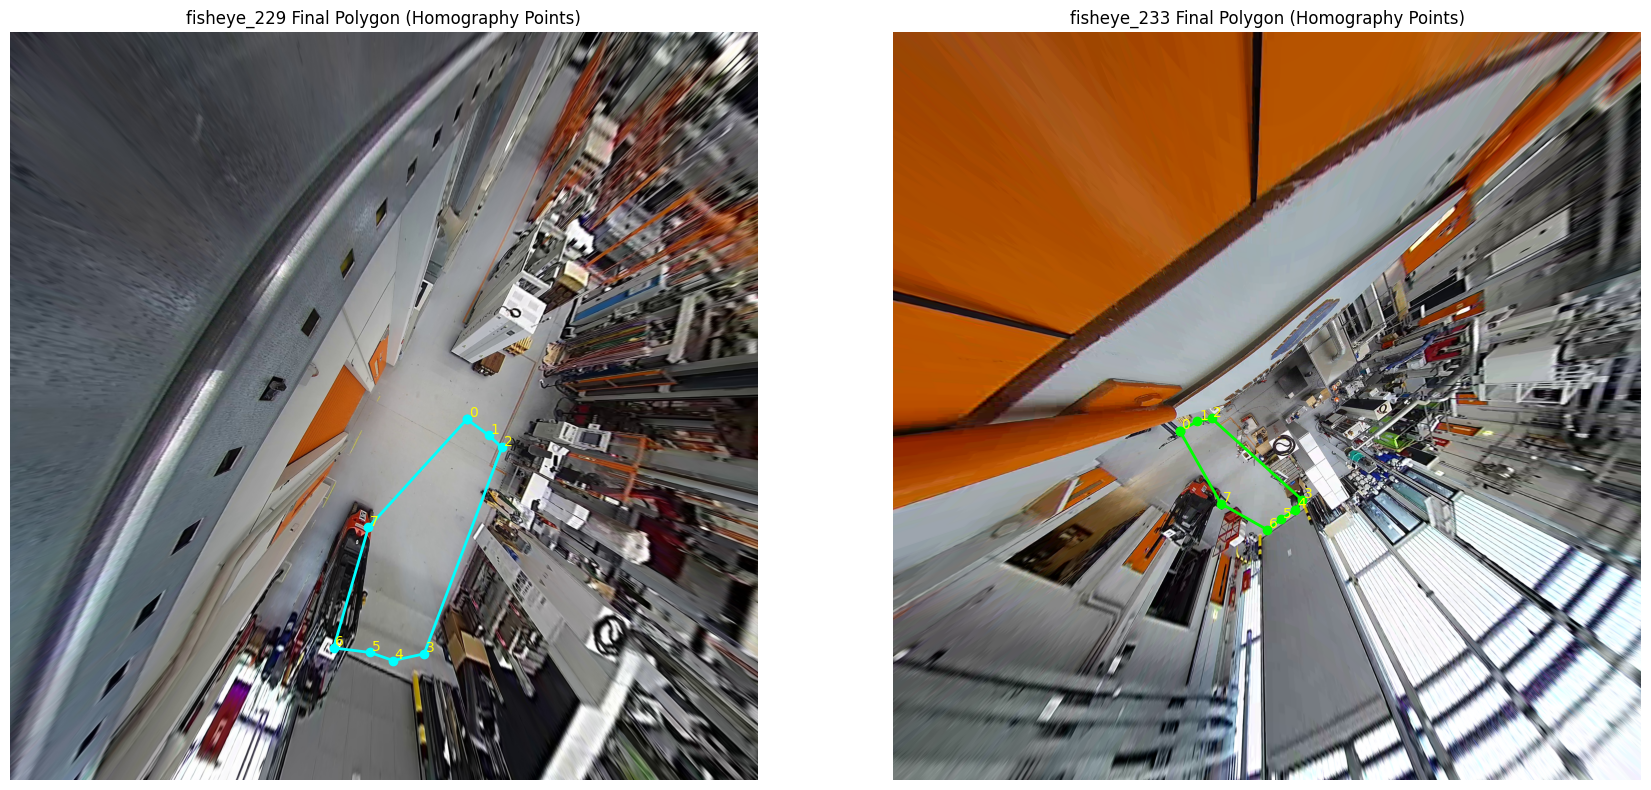

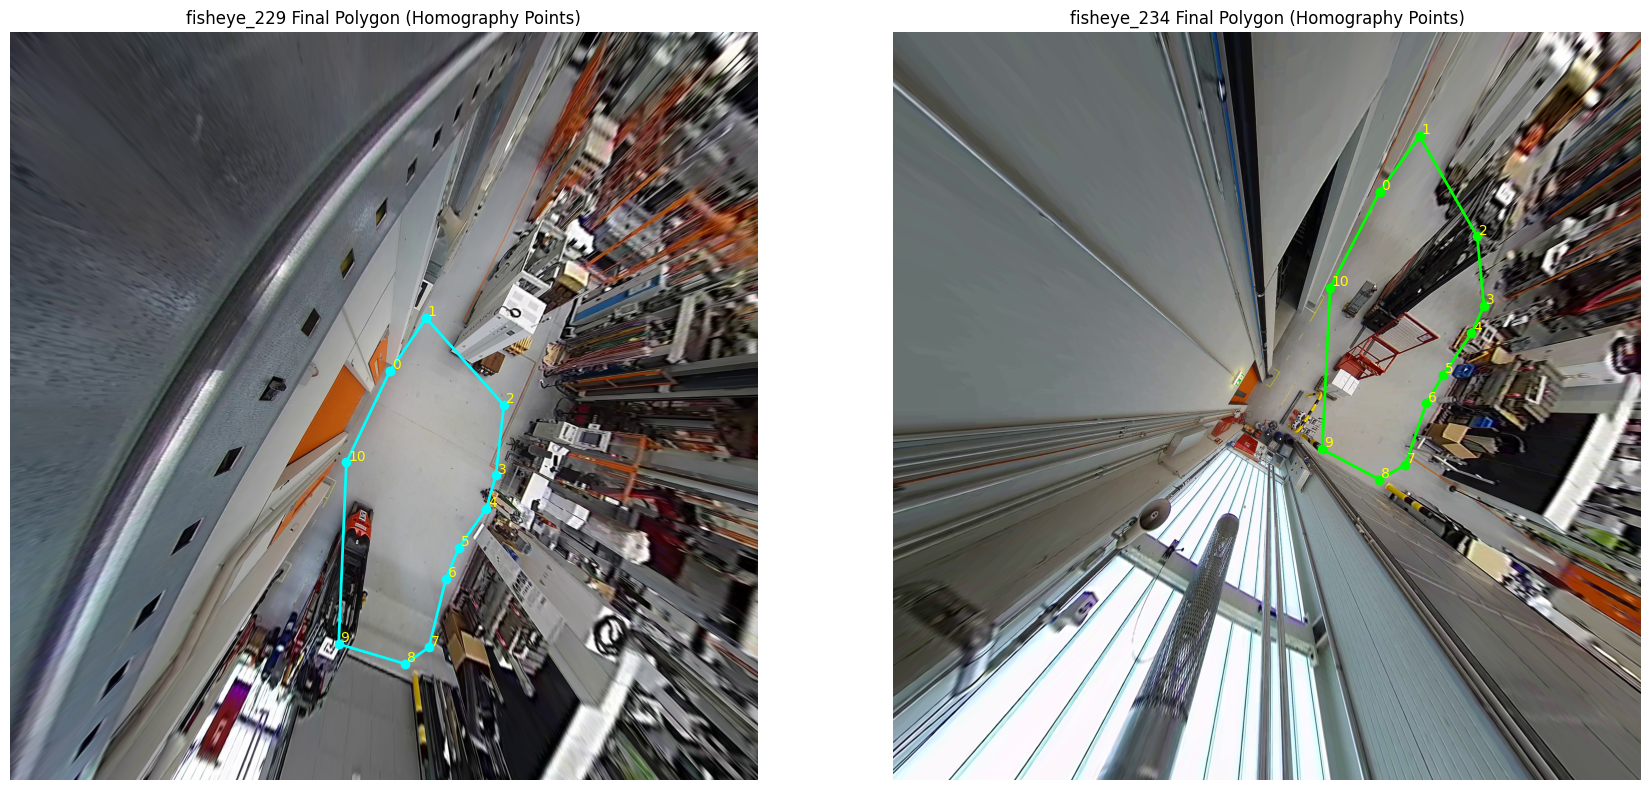

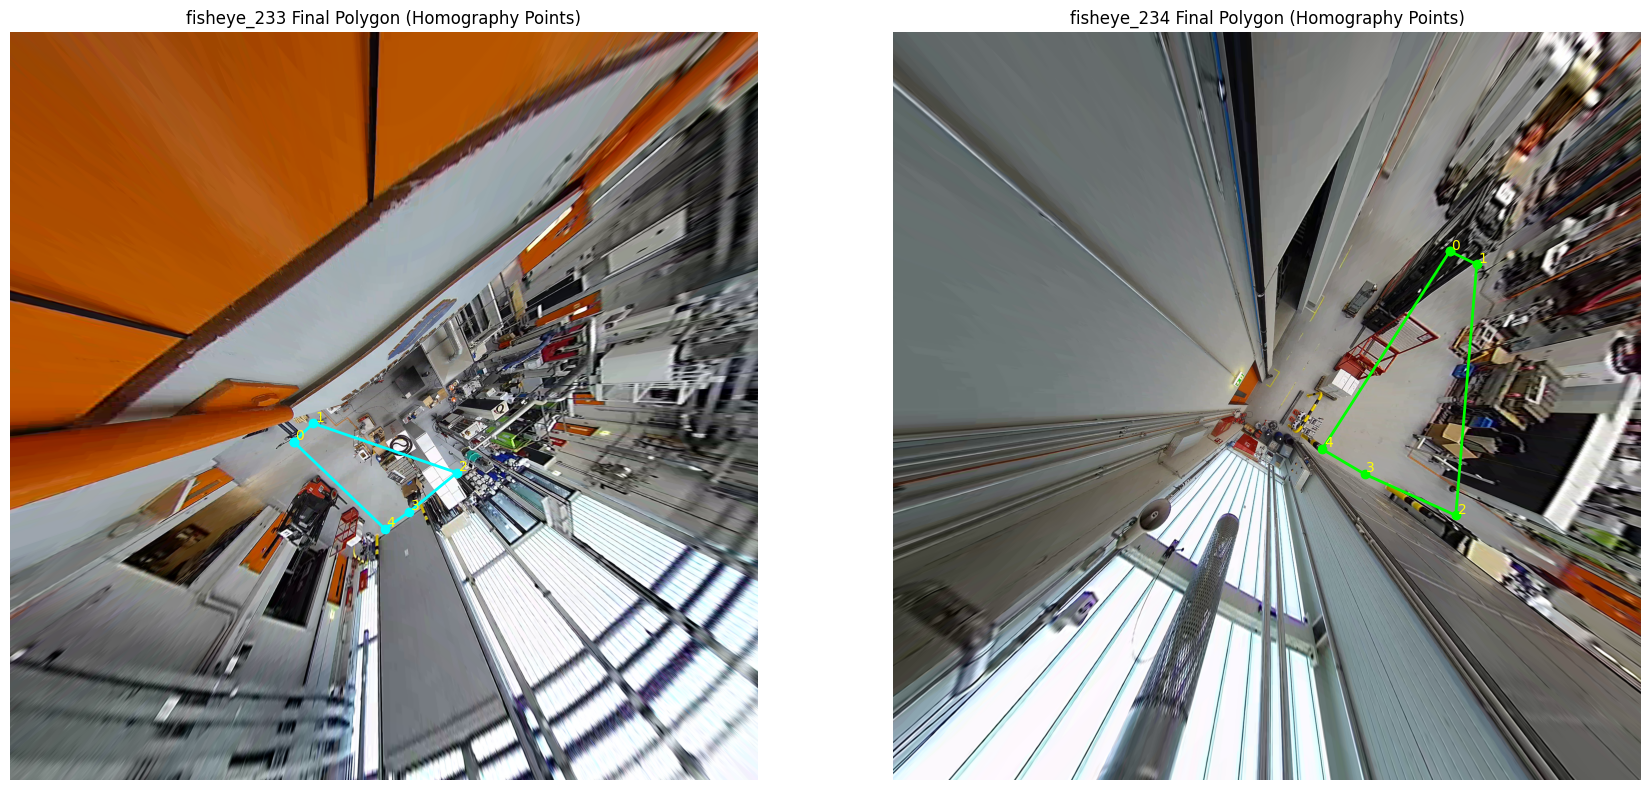

In [35]:

img_229 = cv2.cvtColor(cv2.imread("229_fov/fov_160.jpg"), cv2.COLOR_BGR2RGB)
img_233 = cv2.cvtColor(cv2.imread("cam_4/cam_233_undistort.png"), cv2.COLOR_BGR2RGB)
img_234 = cv2.cvtColor(cv2.imread("cam_4/cam_234_undistort.png"), cv2.COLOR_BGR2RGB)
img_map = {
    "229": img_229,
    "233": img_233,
    "234": img_234
}

def plot_polygon_on_image(ax, img, pts, title, color):
    ax.imshow(img)
    closed = np.vstack([pts, pts[0]])
    ax.plot(
        closed[:, 0],
        closed[:, 1],
        "-o",
        color=color,
        linewidth=2,
        markersize=6
    )

    for i, (x, y) in enumerate(pts):
        ax.text(x + 6, y - 6, str(i), color="yellow", fontsize=10)

    ax.set_title(title)
    ax.axis("off")

for p,val in undistorted_pair_points.items():
    _,a,b = p.split("_")
    fig, axs = plt.subplots(1, 2, figsize=(18, 8))
    plot_polygon_on_image(axs[0],img_map[a], val[0],f"fisheye_{a} Final Polygon (Homography Points)",color="cyan")
    plot_polygon_on_image(axs[1],img_map[b], val[1],f"fisheye_{b} Final Polygon (Homography Points)",color="lime")

    plt.tight_layout()
    plt.show()


In [7]:
for p,val in undistorted_pair_points.items():
    print(p)
    if p == "pair_229_234":
        src = np.array(val[1],np.float32)
        dst = np.array(val[0],np.float32)
        h,mask = cv2.findHomography(src,dst,cv2.RANSAC)
        print(h)

pair_229_233
pair_229_234
[[ 1.35034227e+00 -6.36899542e-02 -6.72157196e+02]
 [ 1.13617108e-01  1.04015442e+00  6.17918817e+02]
 [ 1.38486742e-04 -8.38706887e-05  1.00000000e+00]]
pair_233_234


In [8]:
proj = cv2.perspectiveTransform(src.reshape(-1,1,2), h).reshape(-1,2)
err = np.linalg.norm(proj - dst, axis=1)
print(proj)
print("Mean error:", err.mean())
print("Max error :", err.max())

[[1300.5255 1159.4832]
 [1424.1337  977.4327]
 [1626.6794 1289.6805]
 [1662.8389 1515.9528]
 [1628.3091 1611.7289]
 [1544.1833 1764.6523]
 [1492.2377 1872.3341]
 [1429.9248 2107.7363]
 [1339.6929 2177.1562]
 [1124.7019 2093.7593]
 [1138.4249 1496.9305]]
Mean error: 13.355961
Max error : 65.29757


In [9]:
h_229 = np.load("Homography for 229_camera_.npy")

In [10]:
proj_bev = cv2.perspectiveTransform(proj.reshape(-1,1,2), h_229).reshape(-1,2)
proj_bev

array([[1273.5781 ,  731.2816 ],
       [1224.3671 ,  727.67017],
       [1265.3369 ,  633.3486 ],
       [1308.0695 ,  593.24915],
       [1330.2769 ,  590.8104 ],
       [1365.9885 ,  595.0054 ],
       [1388.9893 ,  595.8514 ],
       [1433.0366 ,  584.6562 ],
       [1448.3633 ,  599.3666 ],
       [1443.9058 ,  657.6712 ],
       [1347.3019 ,  723.4455 ]], dtype=float32)

In [11]:
h_234_to_229_bev = h_229 @ h

In [12]:
proj_234_229_bev = cv2.perspectiveTransform(src.reshape(-1,1,2),h_234_to_229_bev).reshape(-1,2)
proj_234_229_bev

array([[1273.5781 ,  731.2816 ],
       [1224.3671 ,  727.6702 ],
       [1265.3369 ,  633.3486 ],
       [1308.0693 ,  593.24915],
       [1330.2769 ,  590.8104 ],
       [1365.9885 ,  595.0054 ],
       [1388.9893 ,  595.8514 ],
       [1433.0366 ,  584.6562 ],
       [1448.3633 ,  599.3666 ],
       [1443.9058 ,  657.6712 ],
       [1347.3019 ,  723.4455 ]], dtype=float32)

In [13]:
err = np.linalg.norm(proj_234_229_bev - proj_bev, axis=1)
print("Error:", err)
print("Mean error:", err.mean())
print("Max error :", err.max())

Error: [0.0000000e+00 6.1035156e-05 0.0000000e+00 1.2207031e-04 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00]
Mean error: 1.6645952e-05
Max error : 0.00012207031


In [36]:
for p,val in undistorted_pair_points.items():
    print(p)
    if p == "pair_229_234":
        src = np.array(val[1],np.float32)
        dst = np.array(val[0],np.float32)
        h_229_234,mask = cv2.findHomography(src,dst,cv2.RANSAC)
        print(h_229_234)

pair_229_233
pair_229_234
[[ 1.35034227e+00 -6.36899542e-02 -6.72157196e+02]
 [ 1.13617108e-01  1.04015442e+00  6.17918817e+02]
 [ 1.38486742e-04 -8.38706887e-05  1.00000000e+00]]
pair_233_234


In [37]:
for p,val in undistorted_pair_points.items():
    print(p)
    if p == "pair_233_234":
        src_233_234 = np.array(val[0],np.float32)
        dst_233_234 = np.array(val[1],np.float32)
        h_233_234,mask = cv2.findHomography(src_233_234,dst_233_234,cv2.RANSAC)
        print(h_233_234)

pair_229_233
pair_229_234
pair_233_234
[[-1.99210183e-01 -1.09398739e+00  2.51423293e+03]
 [ 3.15210368e-01 -6.78271768e-02  9.90115610e+01]
 [-1.59647597e-04 -3.07804654e-04  1.00000000e+00]]


In [38]:
h_233_234_229 = h_229_234 @ h_233_234

In [39]:
np.save("h_233_234_229.npy",h_233_234_229)

In [40]:
proj_233_234_229 = cv2.perspectiveTransform(src_233_234.reshape(-1,1,2), h_233_234_229).reshape(-1,2)
proj_233_234_229

array([[1541.6312, 1343.6244],
       [1631.1792, 1380.7606],
       [1610.206 , 2254.3037],
       [1285.0815, 2164.9575],
       [1124.7019, 2093.7593]], dtype=float32)

In [41]:
proj_233_234_229_bev = cv2.perspectiveTransform(proj_233_234_229.reshape(-1,1,2), h_229).reshape(-1,2)
proj_233_234_229_bev

array([[1285.3254,  649.0457],
       [1283.6825,  619.9318],
       [1449.9222,  519.2219],
       [1448.6111,  613.7889],
       [1443.9058,  657.6712]], dtype=float32)

In [42]:
h_233_234_229_bev = h_229 @ h_233_234_229

In [43]:
proj_direct_233_234_229_bev = cv2.perspectiveTransform(src_233_234.reshape(-1,1,2), h_233_234_229_bev).reshape(-1,2)
proj_direct_233_234_229_bev

array([[1285.3254,  649.0457],
       [1283.6825,  619.9318],
       [1449.9222,  519.2219],
       [1448.6111,  613.7889],
       [1443.9058,  657.6712]], dtype=float32)

In [44]:
err = np.linalg.norm(proj_direct_233_234_229_bev - proj_233_234_229_bev, axis=1)
print("Error:", err)
print("Mean error:", err.mean())
print("Max error :", err.max())

Error: [0. 0. 0. 0. 0.]
Mean error: 0.0
Max error : 0.0


In [45]:
np.save("proj_direct_no_233_234_229_bev.npy", h_233_234_229_bev)

In [23]:
pair_points = {"pair_229_233":[[2,2,9],[2,3,3]],"pair_234_229":[[2,3,4],[2,2,9]],"pair_233_234":[[2,3,3],[2,3,4]]}

In [24]:
h_ref = np.load("Homography for 229_camera_.npy")

In [25]:
ref = [229,240]
ref_homography = {"229":"Homography for 229_camera_.npy", "240":"Homography for 233_camera_.npy"}
for i in ref:
    a = str(a)
    if a in ref_homography:
        print(ref_homography[a])

In [26]:
homography = {}
ref = [229]
ref_homography = {"229":"Homography for 229_camera_.npy"}
for p,val in undistorted_pair_points.items():
    for ref_cam in ref:
        ref_cam = str(ref_cam)
        print(p)
        _,a,b = p.split("_")
        if a == ref_cam:
            src_pts = np.array(val[1],np.float32)
            dst_pts = np.array(val[0],np.float32)
            key = f"Homography_{b}"
        elif b == ref_cam:
            src_pts = np.array(val[0],np.float32)
            dst_pts = np.array(val[1],np.float32)
            key = f"Homography_{a}"
        else:
            continue
        
        if a in ref_homography:
            print(ref_homography[a])
            h_ref_cam = np.load(ref_homography[a])
            h_relative,mask = cv2.findHomography(src_pts,dst_pts,cv2.RANSAC)
            h_cam_to_bev = h_ref_cam @ h_relative
            if homography.get(ref_cam) is None:
                homography[f"Homography_{ref_cam}"] = h_ref_cam
            if homography.get(key) is None:
                homography[key] = h_cam_to_bev
            else:
                continue



pair_229_233
Homography for 229_camera_.npy
pair_229_234
Homography for 229_camera_.npy
pair_233_234


In [27]:
homography

{'Homography_229': array([[-3.80508158e-01,  2.30400538e-01,  1.20383711e+03],
        [-3.44393073e-01, -5.12837286e-02,  1.06783855e+03],
        [-2.39590097e-04,  6.73004069e-05,  1.00000000e+00]]),
 'Homography_233': array([[ 5.02978704e-01, -3.56972056e-01,  4.36216046e+02],
        [ 8.47880431e-02, -1.00888676e-01,  2.77756377e+02],
        [ 2.94496502e-04, -3.15981752e-04,  4.88128618e-01]]),
 'Homography_234': array([[-3.20923328e-01,  1.62920037e-01,  1.60196724e+03],
        [-3.22993752e-01, -1.20968972e-01,  1.26763565e+03],
        [-1.77395416e-04,  1.39160895e-06,  1.20262840e+00]])}